### **Figure 3.** Longitudinal effects as a function of baseline age group (columns), on raw (upper) and aperiodic-adjusted (lower) power spectra. 

/home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/results
Main directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data
{'Young': {'min_age': 24.3, 'max_age': 47.6, 'min_age_p5': 35.6, 'max_age_p5': 58.7, 'n_subjects': 45}, 'Middle': {'min_age': 47.8, 'max_age': 63.1, 'min_age_p5': 58.9, 'max_age_p5': 74.5, 'n_subjects': 44}, 'Old': {'min_age': 63.2, 'max_age': 84.1, 'min_age_p5': 70.9, 'max_age_p5': 95.5, 'n_subjects': 44}}
Processing age group: Young, N=45
  Processing phase: p2
  Processing phase: p5
Processing age group: Middle, N=44
  Processing phase: p2
  Processing phase: p5
Processing age group: Old, N=44
  Processing phase: p2
  Processing phase: p5


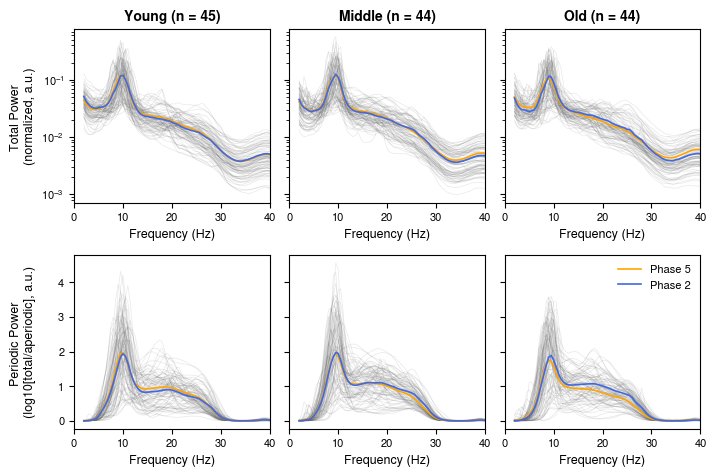

In [1]:
"""
Spectral Power for Longitudinal Effects, separately by Age Groups (Figure 3).

This notebook generates a multi-panel publication figure ("Figure 3") that displays the 
longitudinal changes (Phase 2 vs. Phase 5) separately within three distinct 
age groups: Young, Middle, and Old age groups. This layout provides 
direct visual context for the Age0-by-deltaAge interaction effects modeled 
in the LME regressions.

Author: Maité Crespo García
Affiliation: MRC Cognition and Brain Sciences Unit, Cambridge, UK
Date: 2026 (last modified)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())
datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Main directory: {datadir}')

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

# ---- File with subjects and age in each phase ----
agefile = os.path.join(datadir,f'meglong_rest_age.tsv')

normalize_psd = True
snorm = '_normalized' if normalize_psd else ''

megtype = 'grad' # 'grad', 'mag',

# --- File containing the average spectra for each age group and phase ---
avgspectrafile = os.path.join(datadir, f'avgspectra_{megtype}{snorm}.tsv')

# --- File containing the aperiodic-corrected (periodic) spectra for each age group and phase ---
avgspectrafile_per = os.path.join(datadir, f'avgspectra_{megtype}_per{snorm}.tsv')

age_groups = ['Young', 'Middle', 'Old']

# --- Read in the subjects and age dataframes ---
subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
agedf = pd.read_csv(agefile, sep='\t', index_col=0)
agedf.rename(columns={'p2_meg_age': 'p2_age', 'p5_meg_age': 'p5_age'}, inplace=True)

subjects = subjectsdf.index.tolist()      
agedf = agedf.loc[subjects]
subjectsdf = subjectsdf.loc[subjects]

# --- Define age groups based on age in phase 2 ---
age_bins = np.percentile(agedf['p2_age'], [0, 100/3, 2*100/3, 100])
subjectsdf['Age_group'] = pd.cut(agedf['p2_age'], bins=age_bins, labels=age_groups, include_lowest=True)
agedf.loc[subjects, 'Age_group'] = subjectsdf.loc[subjects, 'Age_group']

# Generate structural summary metrics without using loops
summary_df = agedf.groupby('Age_group', observed=True).agg(
    min_age=('p2_age', 'min'),
    max_age=('p2_age', 'max'),
    min_age_p5=('p5_age', 'min'),
    max_age_p5=('p5_age', 'max'),
    n_subjects=('p2_age', 'count')
)

# Convert directly to a dictionary matching your original schema
age_groups_dict = summary_df.to_dict(orient='index')

print(age_groups_dict)

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'royalblue'},
    'p5': {'label': 'Phase 5', 'color': 'orange'}
}

fitting_param = 'finley'

# General figure settings
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"] 
plt.rcParams.update({'font.size': 8})

if normalize_psd:
    chan_units = '(normalized, a.u.)'

# --- Create the figure and axes for plotting ---
fig, axs = plt.subplots(2, len(age_groups), figsize=(7.2, 5), gridspec_kw={'wspace': 0.1, 'hspace': 0.3, 'left':0.10, 'right':0.97, 'top':0.91, 'bottom':0.11}, sharey='row')

avgspectra = pd.read_csv(avgspectrafile, sep='\t') # DataFrame with the average spectra for each age group and phase (for the total power spectra, Upper-row plots)
avgspectra.drop(columns=['Freq_1.0Hz', 'Freq_1.5Hz'], inplace=True)
freqs_columns = [col for col in avgspectra.columns if col.startswith('Freq_')]
freqs = np.array([float(col.split('_')[1].split('H')[0]) for col in freqs_columns]) # Extract frequencies from column names

avgspectra_per = pd.read_csv(avgspectrafile_per, sep='\t') # DataFrame with the average spectra for each age group and phase (for the aperiodic-corrected spectra, Lower-row plots)

avgspectra['Age_group'] = avgspectra['Subject'].map(agedf['Age_group'])
avgspectra_per['Age_group'] = avgspectra_per['Subject'].map(agedf['Age_group'])

for group, group_dict in age_groups_dict.items():
    # select subjects in the age group
    group_subjects = agedf[agedf['Age_group'] == group].index.tolist()
    print(f'Processing age group: {group}, N={len(group_subjects)}')

    g = age_groups.index(group)        

    phases_spectra = []
    for phase in phases:
        print(f'  Processing phase: {phase}')

        # loop over subjects
        for id in group_subjects: 
            armx = subjectsdf.loc[id,'arm']        
        
            spectra = avgspectra.loc[(avgspectra['Subject'] == id) & (avgspectra['Phase'] == phase), freqs_columns].values.flatten() # Extract the average spectrum for this subject and phase (for the total power spectra, Upper-row plots)

            spectra_per = avgspectra_per.loc[(avgspectra_per['Subject'] == id) & (avgspectra_per['Phase'] == phase), freqs_columns].values.flatten() # Extract the average aperiodic-corrected spectrum for this subject and phase (for the lower-row plots)
            
            freqs_per = freqs.copy() # Frequencies are the same for total and aperiodic-corrected spectra, so we can just copy them

            ax = axs[0, g]
            ax.plot(freqs, spectra, color='dimgrey', linewidth=0.5, alpha=0.15)
            del spectra # free memory
            
            ax = axs[1, g]
            ax.plot(freqs_per, spectra_per, color='dimgrey', linewidth=0.5, alpha=0.15)
            del spectra_per # free memory

    group_phase2_mean = avgspectra.loc[(avgspectra['Phase'] == 'p2') & (avgspectra['Age_group'] == group), freqs_columns].mean().values.flatten()
    group_phase5_mean = avgspectra.loc[(avgspectra['Phase'] == 'p5') & (avgspectra['Age_group'] == group), freqs_columns].mean().values.flatten()

    group_phase2_mean_per = avgspectra_per.loc[(avgspectra_per['Phase'] == 'p2') & (avgspectra_per['Age_group'] == group), freqs_columns].mean().values.flatten()
    group_phase5_mean_per = avgspectra_per.loc[(avgspectra_per['Phase'] == 'p5') & (avgspectra_per['Age_group'] == group), freqs_columns].mean().values.flatten()

    # Plot group spectra
    ax = axs[0, g]

    if True: # whether to plot grand average spectra for each group and phase
        ax.plot(freqs, group_phase5_mean, label='Phase 5', color=phases_dict['p5']['color'], linewidth=1.2)
        ax.plot(freqs, group_phase2_mean, label='Phase 2', color=phases_dict['p2']['color'], linewidth=1.2)
    
    ax.set_title(f'{group} (n = {group_dict["n_subjects"]})', fontsize=10, fontweight='bold') #
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    if age_groups.index(group) == 0:
        ax.set_ylabel(f'Total Power \n{chan_units}', fontsize=9)
    ax.set_xlim(0, 40)
    ax.set_yscale('log')

    # Plot aperiodic-corrected spectra
    ax = axs[1, g]
    ax.plot(freqs_per, group_phase5_mean_per, label='Phase 5', color=phases_dict['p5']['color'], linewidth=1.2)
    ax.plot(freqs_per, group_phase2_mean_per, label='Phase 2', color=phases_dict['p2']['color'], linewidth=1.2)

    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    if age_groups.index(group) == 0:
        ax.set_ylabel(f'Periodic Power \n(log10[total/aperiodic], a.u.)', fontsize=9)
    ax.set_xlim(0, 40)

plt.legend(frameon=False, fontsize=8, loc='upper right')
fig.align_ylabels(axs[:,0])
plt.savefig(os.path.join(f'Figure03.png'), dpi=300, format='png', transparent=False)
plt.show()